# 05 Predictor Agreement

Question: Do predictors agree more than annotations do?

This notebook summarizes pairwise agreement between human-proteome predictor outputs and compares that agreement with the experimental annotation-agreement estimates from the annotation ceiling analysis.

## Method

The predictor comparison uses matched residues from the same human proteome proteins. For every predictor pair, the script reports residue-level Spearman/Pearson correlation, protein-mean Spearman/Pearson correlation, and z-score MAE. CheZOD and pLDDT are negated before comparison because their native direction is lower = more disorder.

The annotation comparison joins each predictor pair to the matching annotation-ceiling pair. The main diagnostic is the difference between predictor Spearman and annotation Spearman. Positive values mean the trained predictors agree more strongly with each other than the underlying annotations agree on overlapping experimental data.

In [41]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS = ROOT / "results"
OUTPUT_DIR = RESULTS / "compare_predictors_with_seth_and_iupred3_and_adopt_and_metapredict"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pairwise_csv = OUTPUT_DIR / "pairwise_agreement.csv"
contested_csv = OUTPUT_DIR / "contested_regions.csv"

predictor_args = [
    "trizod=results/human_proteome/UdonPred/trizod",
    "chezod=results/human_proteome/UdonPred/chezod",
    "softdis=results/human_proteome/UdonPred/softdis",
    "pdbflex=results/human_proteome/UdonPred/pdbflex",
    "atlas=results/human_proteome/UdonPred/atlas",
    "plddt=results/human_proteome/UdonPred/plddt",
    "disprot=results/human_proteome/UdonPred/disprot",
    "SETH=results/human_proteome/SETH/seth_human_proteome.caid",
    "IUPred3=results/human_proteome/IUPred3",
    "ADOPT=results/human_proteome/ADOPT",
    "metapredict=results/human_proteome/metapredict/metapredict_human_proteome.caid",
]

if pairwise_csv.exists() and contested_csv.exists():
    print("Predictor comparison results already exist, skipping computation.")
else:
    print("Running predictor comparison...")
    cmd = [sys.executable, str(ROOT / "scripts" / "compare_predictors.py")]
    for value in predictor_args:
        cmd.extend(["--predictor", value])
    cmd.extend(["--output-dir", str(OUTPUT_DIR)])
    result = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    result.check_returncode()

pairwise = pd.read_csv(pairwise_csv)
contested_regions = pd.read_csv(contested_csv)

pairwise.head()

Predictor comparison results already exist, skipping computation.


,predictor_a,predictor_b,common_proteins,matched_residues,residue_spearman,residue_pearson,residue_zscore_mae,protein_spearman,protein_pearson,protein_zscore_mae
0,ADOPT,IUPred3,20659,9861047,0.637572,0.712196,0.600289,0.704414,0.741337,0.539165
1,ADOPT,SETH,20659,9861047,0.808299,0.875295,0.381239,0.933621,0.948784,0.238737
2,ADOPT,atlas,20659,9861047,0.716855,0.718688,0.548962,0.850849,0.804915,0.448031
3,ADOPT,chezod,20659,9861047,0.803898,0.873617,0.392639,0.919019,0.935593,0.264353
4,ADOPT,disprot,20659,9861047,0.784306,0.880197,0.378025,0.923026,0.935496,0.265379


## Predictor-Predictor Agreement

Residue-level correlation asks whether predictors rank individual residues similarly. Protein-level correlation asks whether they agree on which proteins are globally more disorder-prone.

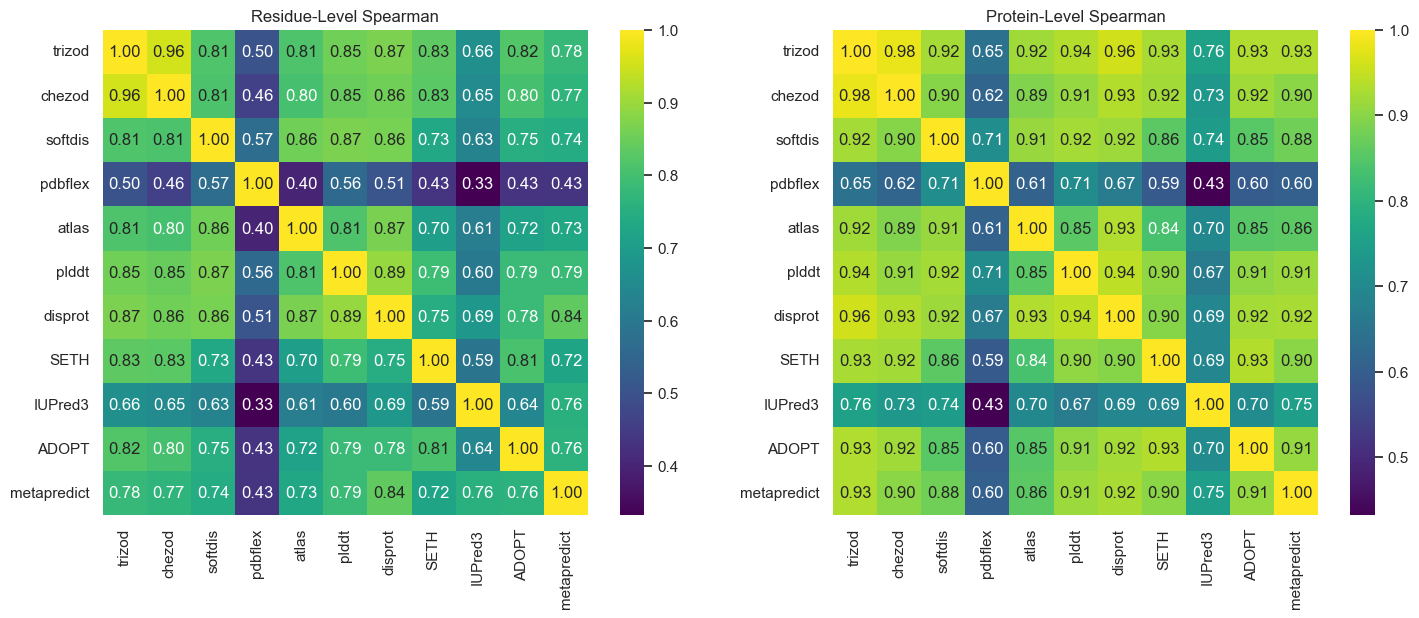

,predictor_a,predictor_b,common_proteins,matched_residues,residue_spearman,residue_pearson,residue_zscore_mae,protein_spearman,protein_pearson,protein_zscore_mae
39,chezod,trizod,20659,11456702,0.955227,0.962036,0.221924,0.980046,0.982735,0.139842
42,disprot,plddt,20659,11456702,0.894091,0.940588,0.249930,0.942352,0.927614,0.276945
52,plddt,softdis,20659,11456702,0.868132,0.910745,0.303695,0.923485,0.918080,0.262247
44,disprot,trizod,20659,11456702,0.867406,0.938770,0.246672,0.958151,0.954381,0.206561
28,atlas,disprot,20659,11456702,0.866774,0.799895,0.429647,0.933264,0.888480,0.324899
43,disprot,softdis,20659,11456702,0.863369,0.877606,0.330251,0.917692,0.881364,0.307246
32,atlas,softdis,20659,11456702,0.855393,0.789845,0.459573,0.912408,0.849228,0.359305
34,chezod,disprot,20659,11456702,0.855081,0.925031,0.292262,0.934552,0.952239,0.230152
53,plddt,trizod,20659,11456702,0.854218,0.924289,0.287333,0.935306,0.930619,0.283650
37,chezod,plddt,20659,11456702,0.845469,0.915369,0.320752,0.909845,0.917951,0.313763


In [42]:
predictor_order = [
    name
    for name in ["trizod", "chezod", "softdis", "pdbflex", "atlas", "plddt", "disprot", "SETH", "IUPred3", "ADOPT", "metapredict"]
    if name in set(pairwise["predictor_a"]) | set(pairwise["predictor_b"])
]

def pair_matrix(value_column):
    matrix = pd.DataFrame(np.nan, index=predictor_order, columns=predictor_order)
    for predictor in predictor_order:
        matrix.loc[predictor, predictor] = 1.0
    for row in pairwise.itertuples(index=False):
        matrix.loc[row.predictor_a, row.predictor_b] = getattr(row, value_column)
        matrix.loc[row.predictor_b, row.predictor_a] = getattr(row, value_column)
    return matrix

residue_spearman_matrix = pair_matrix("residue_spearman")
protein_spearman_matrix = pair_matrix("protein_spearman")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(
    residue_spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=np.nanmin(residue_spearman_matrix.values),
    vmax=1,
    square=True,
    ax=axes[0],
)
axes[0].set_title("Residue-Level Spearman")
sns.heatmap(
    protein_spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=np.nanmin(protein_spearman_matrix.values),
    vmax=1,
    square=True,
    ax=axes[1],
)
axes[1].set_title("Protein-Level Spearman")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "predictor_spearman_heatmaps.png", dpi=200)
plt.show()

pairwise.sort_values("residue_spearman", ascending=False)

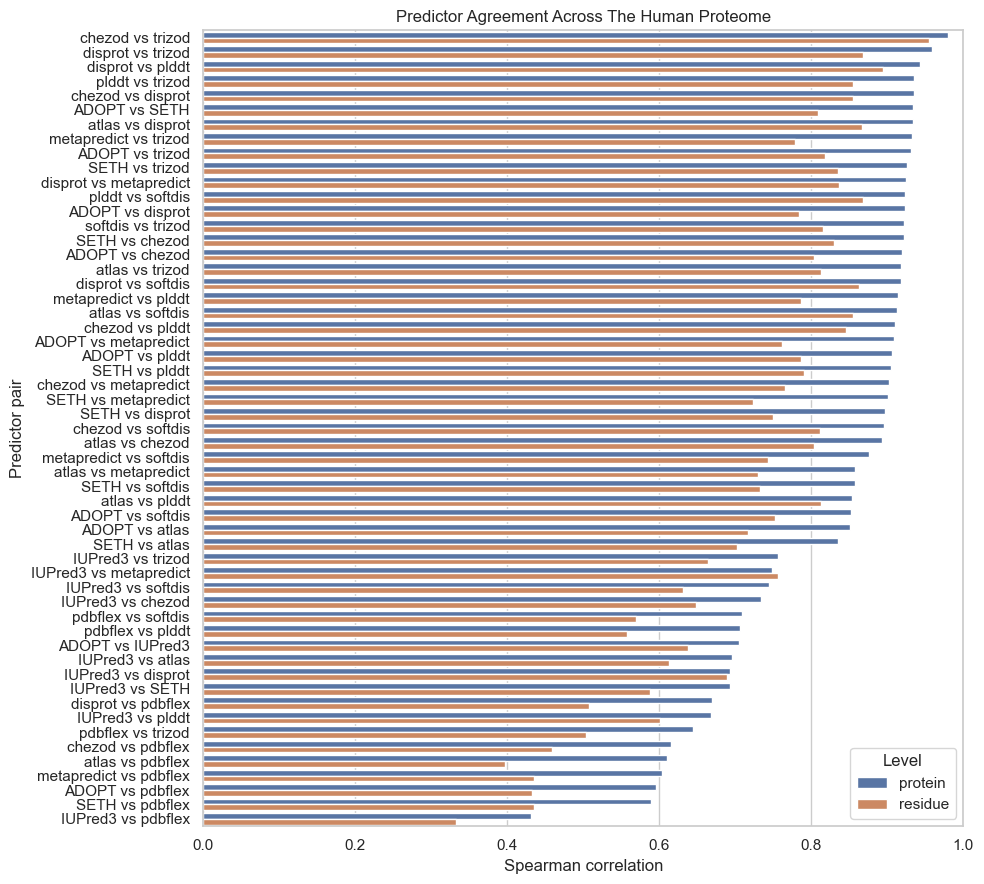

In [43]:
agreement_long = pairwise.melt(
    id_vars=["predictor_a", "predictor_b", "common_proteins", "matched_residues"],
    value_vars=["residue_spearman", "protein_spearman"],
    var_name="level",
    value_name="spearman",
)
agreement_long["pair"] = agreement_long["predictor_a"] + " vs " + agreement_long["predictor_b"]
agreement_long["level"] = agreement_long["level"].str.replace("_spearman", "", regex=False)

plot_data = agreement_long.sort_values(["level", "spearman"], ascending=[True, False])

plt.figure(figsize=(10, 9))
sns.barplot(data=plot_data, x="spearman", y="pair", hue="level")
plt.xlabel("Spearman correlation")
plt.ylabel("Predictor pair")
plt.title("Predictor Agreement Across The Human Proteome")
plt.xlim(0, 1)
plt.legend(title="Level", loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "predictor_pairwise_spearman_bars.png", dpi=200)
plt.show()